In [1]:
""" import sys
!"{sys.executable}" -m pip install pingouin
!"{sys.executable}" -m pip install scikit_posthocs """

import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
#from cliffs_delta import cliffs_delta
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
baseline = pd.read_csv('BCEA_BaselineValues2.csv')
ride = pd.read_csv('BCEA_RideValues2.csv')
fog=pd.read_csv('BCEA_FogValues2.csv')


In [3]:

# Convert 'Gender' to numeric if it exists
for df in [baseline, ride, fog]:
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

# Then select only numeric columns
# Then select only numeric columns
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num     = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])
#baseline_num.head()
merged = pd.concat([baseline, ride, fog], ignore_index=True)
merged.head()



,SubjectID,MeanHoriz,StdHoriz,MeanVert,StdVert,RHO,BCEA,Estimated PRL,Guziks Index,MSE,Sample Entropy Horiz,App Entropy Horiz,Sample Entropy Vert,App Entropy Vert
0,x1703_01_gazedata_output,5.151988,3.126788,8.066502,5.906800,-0.074533,347.169991,2,0.277461,11003.132930,0.060879,0.142565,0.033707,0.129698
1,x1703_02_gazedata_output,-24.018464,3.853317,11.428652,3.459394,0.019379,251.220116,3,0.803201,1990.131005,0.162610,0.104444,0.259139,0.117033
2,x1703_03_gazedata_output,-2.130202,4.850855,8.002638,6.631971,0.166508,597.938609,3,0.490336,18469.199950,0.050693,0.203427,0.025032,0.163494
3,x1703_05_gazedata_output,0.806637,8.946961,6.926136,5.480803,-0.086105,920.883917,2,0.369209,58179.802110,0.060185,0.091366,0.064590,0.108698
4,x1703_06_gazedata_output,37.424268,2.326935,9.447647,6.186620,0.181227,266.862287,2,0.135363,13326.135540,0.066141,0.162173,0.030558,0.199578


In [4]:
# napravi kopije sa sufiksima
base = baseline.copy()
base = base.add_suffix('_Baseline')
base = base.rename(columns={'SubjectID_Baseline': 'SubjectID'})

ride_df = ride.copy()
ride_df = ride_df.add_suffix('_Ride')
ride_df = ride_df.rename(columns={'SubjectID_Ride': 'SubjectID'})

fog_df = fog.copy()
fog_df = fog_df.add_suffix('_Fog')
fog_df = fog_df.rename(columns={'SubjectID_Fog': 'SubjectID'})


# spoji po SubjectID
merged = base.merge(ride_df, on='SubjectID', how='inner') \
             .merge(fog_df, on='SubjectID', how='inner') 
print(merged.head())


                  SubjectID  MeanHoriz_Baseline  StdHoriz_Baseline  \
0  x1703_01_gazedata_output            5.151988           3.126788   
1  x1703_02_gazedata_output          -24.018464           3.853317   
2  x1703_03_gazedata_output           -2.130202           4.850855   
3  x1703_05_gazedata_output            0.806637           8.946961   
4  x1703_06_gazedata_output           37.424268           2.326935   

   MeanVert_Baseline  StdVert_Baseline  RHO_Baseline  BCEA_Baseline  \
0           8.066502          5.906800     -0.074533     347.169991   
1          11.428652          3.459394      0.019379     251.220116   
2           8.002638          6.631971      0.166508     597.938609   
3           6.926136          5.480803     -0.086105     920.883917   
4           9.447647          6.186620      0.181227     266.862287   

   Estimated PRL_Baseline  Guziks Index_Baseline  MSE_Baseline  ...  \
0                       2               0.277461  11003.132930  ...   
1         

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, friedmanchisquare
import pingouin as pg
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# --- funkcija za Cliff's delta ---
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    gt = sum(xx > yy for xx in x for yy in y)
    lt = sum(xx < yy for xx in x for yy in y)
    delta = (gt - lt) / (nx * ny)
    # interpretacija
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        interp = "negligible"
    elif abs_delta < 0.33:
        interp = "small"
    elif abs_delta < 0.474:
        interp = "medium"
    else:
        interp = "large"
    return delta, interp

labels = ['Baseline','Ride','Fog']
variables = ['MeanHoriz', 'StdHoriz','MeanVert','StdVert',	'RHO',	'BCEA',	'Estimated PRL','Guziks Index',	'MSE',	'Sample Entropy Horiz',	'App Entropy Horiz','Sample Entropy Vert',	'App Entropy Vert']

all_results = []

for var in variables:
    # --- select columns for current variable ---
    cols_var = [c for c in merged.columns if c.startswith(f"{var}_")]
    if not cols_var:
        continue

    # --- melt u long format ---
    long_df = pd.melt(
        merged,
        id_vars='SubjectID',
        value_vars=cols_var,
        var_name='Condition',
        value_name='Value'
    )
    for lab in labels:
        long_df['Condition'] = long_df['Condition'].str.replace(f"{var}_{lab}", lab, regex=False)
    long_df['Condition'] = long_df['Condition'].str.strip()

    # --- normalnost ---
    # normal_flags = []
    # for cond in labels:
    #     vals = long_df.loc[long_df['Condition']==cond, 'Value'].dropna()
    #     if len(vals) >= 3:
    #         normal_flags.append(shapiro(vals).pvalue > 0.05)
    #     else:
    #         normal_flags.append(False)
    # all_normal = all(normal_flags)
    # --- Normality check with Shapiro–Wilk ---
    normality_info = {}
    for cond in labels:
        vals = long_df.loc[long_df['Condition']==cond, 'Value'].dropna()
        if len(vals) >= 3:
            stat, p_val = shapiro(vals)
            normality_info[cond] = {
                'p_value': p_val,
                'status': 'Normal' if p_val > 0.05 else 'Not normal'
            }
        else:
            normality_info[cond] = {'p_value': np.nan, 'status': 'Not enough data'}

    all_normal = all(
        info['status'] == 'Normal'
        for info in normality_info.values()
    )


    # --- wide format po subjectu ---
    wide = long_df.pivot(index="SubjectID", columns="Condition", values="Value")
    wide = wide.dropna()

    # --- globalni test ---
    if all_normal and wide.shape[0] > 1:
        aov = pg.rm_anova(dv='Value', within='Condition', subject='SubjectID', data=long_df, detailed=True)
        p_global = aov['p-GG-corr'].iloc[0] if 'p-GG-corr' in aov else aov['p-unc'].iloc[0]
        stat_global = aov['F'].iloc[0]
        test_used = 'RM-ANOVA'
    else:
        if wide.shape[1] >= 3 and wide.shape[0] > 0:
            stat_global, p_global = friedmanchisquare(*[wide[c].values for c in wide.columns])
            test_used = 'Friedman'
        else:
            stat_global, p_global = np.nan, np.nan
            test_used = 'Friedman (premalo pod.)'

    # --- interpretacija globalnog testa ---
    if np.isnan(p_global):
        interp_global = "Insufficient data"
    elif p_global < 0.05:
        interp_global = "Significant effect of Condition"
    else:
        interp_global = "No significant effect of Condition"

    # --- post-hoc testovi ---
    posthoc_list = []
    for cond1, cond2 in combinations(labels, 2):
        if cond1 in wide.columns and cond2 in wide.columns:
            v1 = wide[cond1].fillna(wide[cond1].median())
            v2 = wide[cond2].fillna(wide[cond2].median())
            
            if len(v1) > 1 and len(v2) > 1:
                if test_used=='RM-ANOVA':
                    t_res = pg.ttest(v1, v2, paired=True)
                    p_val = t_res['p-val'].iloc[0]
                    eff_val = pg.compute_effsize(v1,v2,paired=True,eftype='cohen')
                    eff_type = "Cohen_d"
                else:
                    try:
                        w_res = pg.wilcoxon(v1, v2)
                        p_val = w_res['p-val'].iloc[0]
                    except:
                        p_val = np.nan
                    eff_val, eff_label = cliffs_delta(v1,v2)
                    eff_type = "Cliffs_delta"
                posthoc_list.append({
                    'Cond1':cond1,
                    'Cond2':cond2,
                    'p_posthoc':p_val,
                    'Effect':eff_val,
                    'Eff_type':eff_type
                })

    # --- FDR korekcija unutar jedne varijable ---
    if posthoc_list:
    # --- Extract p-values and apply FDR correction ---
        pvals = [ph['p_posthoc'] for ph in posthoc_list]
        reject, pvals_corr, _, _ = multipletests(pvals, method='fdr_bh')

        # --- Define thresholds ---
        cliffs_thresholds = [
            (0.147, 'negligible'),
            (0.33, 'small'),
            (0.474, 'medium'),
            (0.706, 'large'),
            (float('inf'), 'very large')
        ]

        cohens_thresholds = [
            (0.2, 'small'),
            (0.5, 'medium'),
            (0.8, 'large'),
            (1.2, 'very large'),
            (float('inf'), 'huge')
        ]

        # --- Apply correction and interpretation ---
        for i, ph in enumerate(posthoc_list):
            ph['p_FDR'] = pvals_corr[i]
            ph['Significant_FDR'] = reject[i]

            if not reject[i]:
                ph['Interpretation'] = "No significant difference"
                continue

            effect = ph['Effect']
            direction = "higher" if effect > 0 else "lower"
            abs_effect = abs(effect)

            if ph['Eff_type'] == 'Cliffs_delta':
                magnitude = next((label for t, label in cliffs_thresholds if abs_effect < t), 'very large')
            else:  # Cohen’s d
                magnitude = next((label for t, label in cohens_thresholds if abs_effect < t), 'huge')

            ph['Interpretation'] = (
                f"{ph['Cond1']} is {direction} than {ph['Cond2']} "
                f"({magnitude} effect, {ph['Eff_type']} = {effect:.3f}, p_FDR = {pvals_corr[i]:.4f})"
        )
    normality_dict = {cond: info['status'] for cond, info in normality_info.items()}

    # --- sacuvaj ---
    all_results.append({
    'Variable': var,
    'Normality': normality_info,
    'All_normal': all_normal,
    'Long_df': long_df,
    'Global_test': test_used,
    'Global_stat': stat_global,
    'Global_p': p_global,
    'Global_interp': interp_global,
    'Posthoc': posthoc_list
})


# --- sacuvaj CSV ---
summary_list = []
for res in all_results:
    var = res['Variable']
    for ph in res['Posthoc']:
        summary_list.append({
            'Variable': var,
            'Normality_Baseline': res['Normality'].get('Baseline', {}).get('status', ''),
            'Normality_Ride': res['Normality'].get('Ride', {}).get('status', ''),
            'Normality_Fog': res['Normality'].get('Fog', {}).get('status', ''),
            'p_Shapiro_Baseline': res['Normality'].get('Baseline', {}).get('p_value', np.nan),
            'p_Shapiro_Ride': res['Normality'].get('Ride', {}).get('p_value', np.nan),
            'p_Shapiro_Fog': res['Normality'].get('Fog', {}).get('p_value', np.nan),
            'All_normal': res.get('All_normal', ''),
            'Global_test': res['Global_test'],
            'Global_stat': res['Global_stat'],
            'Global_p': res['Global_p'],
            'Global_interp': res.get('Global_interp', ''),
            'Cond1': ph['Cond1'],
            'Cond2': ph['Cond2'],
            'p_posthoc': ph['p_posthoc'],
            'p_FDR': ph.get('p_FDR', np.nan),
            'Significant_FDR': ph.get('Significant_FDR', False),
            'Effect': ph['Effect'],
            'Eff_type': ph['Eff_type'],
            'Interpretation': ph.get('Interpretation', '')
        })

summary_df = pd.DataFrame(summary_list)
summary_df.to_csv("anova_friedman_results2.csv", index=False)
print("✅ Gotov fajl: anova_friedman_results.csv sa interpretacijom rezultata.")


✅ Gotov fajl: anova_friedman_results.csv sa interpretacijom rezultata.


In [6]:
import statsmodels.stats.multitest as smm
summary_list_posthoc = []

for res in all_results:
    var = res['Variable']
    posthoc = res['Posthoc']
    if not posthoc:
        continue

    pvals = [ph['p_posthoc'] for ph in posthoc]
    reject, pvals_fdr, _, _ = smm.multipletests(pvals, alpha=0.05, method='fdr_bh')

    for ph, fdr_val, sig in zip(posthoc, pvals_fdr, reject):
        summary_list_posthoc.append({
            "Variable": var,
            "Global_test": res['Global_test'],
            "Global_p": res['Global_p'],
            "Condition1": ph['Cond1'],
            "Condition2": ph['Cond2'],
            "p_posthoc": ph['p_posthoc'],
            "Effect": ph['Effect'],
            "Eff_type": ph['Eff_type'],
            "p_FDR": fdr_val,
            "Significant_FDR": sig,
            "Interpretation": ph.get('Interpretation', '')
        })

summary_df_posthoc = pd.DataFrame(summary_list_posthoc)
summary_df_posthoc.to_csv("posthoc_summary_with_FDR2.csv", index=False)
print("✅ Dodatni fajl sačuvan: posthoc_summary_with_FDR.csv")

✅ Dodatni fajl sačuvan: posthoc_summary_with_FDR.csv


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# ================================
# 1️⃣ Učitaj i spoji fajlove
# ================================
baseline = pd.read_csv("BCEA_BaselineValues.csv")
ride = pd.read_csv("BCEA_RideValues.csv")
fog = pd.read_csv("BCEA_FogValues.csv")

# Dodaj kolonu Condition
baseline['Condition'] = 'Baseline'
ride['Condition'] = 'Ride'
fog['Condition'] = 'Fog'

# Spoji u jedan DataFrame
merged = pd.concat([baseline, ride, fog], ignore_index=True)

# ================================
# 2️⃣ Pretvori u long format
# ================================
value_vars = [col for col in merged.columns if col not in ['SubjectID','Condition']]
df_long = merged.melt(id_vars=['SubjectID','Condition'], value_vars=value_vars,
                      var_name='Variable', value_name='Value')

# ================================
# 3️⃣ Pairwise post-hoc testovi
# ================================
from itertools import combinations

results = []

conditions = ['Baseline','Ride','Fog']

for var in df_long['Variable'].unique():
    df_var = df_long[df_long['Variable']==var]
    for cond1, cond2 in combinations(conditions, 2):
        data1 = df_var[df_var['Condition']==cond1]['Value']
        data2 = df_var[df_var['Condition']==cond2]['Value']
        # Paired test, t-test ili Wilcoxon
        try:
            stat, p = ttest_rel(data1, data2)
        except:
            stat, p = np.nan, np.nan
        # Cliff's delta effect size
        def cliffs_delta(x,y):
            more = sum([xi>yi for xi in x for yi in y])
            less = sum([xi<yi for xi in x for yi in y])
            n = len(x)*len(y)
            return (more-less)/n
        delta = cliffs_delta(data1, data2)
        # Interpretacija efekta
        abs_delta = abs(delta)
        if abs_delta < 0.147:
            eff_type = 'negligible'
        elif abs_delta < 0.33:
            eff_type = 'small'
        elif abs_delta < 0.474:
            eff_type = 'medium'
        else:
            eff_type = 'large'
        results.append([var, cond1, cond2, p, delta, eff_type])

df_results = pd.DataFrame(results, columns=['Variable','Condition1','Condition2','p','Eff_size','Eff_type'])

# FDR korekcija po svim parovima
df_results['p_FDR'] = multipletests(df_results['p'], method='fdr_bh')[1]
df_results['Significant_FDR'] = df_results['p_FDR'] < 0.05

# ================================
# 4️⃣ Line plot po varijablama
# ================================
plt.figure(figsize=(12,6))

for var in df_long['Variable'].unique():
    df_var = df_long[df_long['Variable']==var]
    y_vals = [df_var[df_var['Condition']==cond]['Value'].mean() for cond in conditions]
    # boja ako bar jedan par značajan
    sig_any = df_results[df_results['Variable']==var]['Significant_FDR'].any()
    color = 'blue' if sig_any else 'gray'
    plt.plot(range(len(conditions)), y_vals, marker='o', color=color, alpha=0.7)
    plt.text(len(conditions)-0.5, y_vals[-1], var, fontsize=9, va='center')

plt.xticks(range(len(conditions)), conditions)
plt.ylabel('Mean Value')
plt.title('Changes Across Conditions (Line Plot) with FDR Significance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ================================
# 5️⃣ Log p-value bar plot
# ================================
plt.figure(figsize=(14,6))
bars = plt.bar(range(len(df_results)), df_results['p_FDR'], color='skyblue', edgecolor='black')
plt.axhline(0.05, color='red', linestyle='--', label='Threshold 0.05')
for bar, sig in zip(bars, df_results['Significant_FDR']):
    if sig:
        bar.set_color('orange')
plt.yscale('log')
plt.ylabel('p-value (log scale)')
plt.xticks(range(len(df_results)), df_results.apply(lambda x: f"{x['Condition1']}→{x['Condition2']} ({x['Variable']})", axis=1), rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Post-hoc Pairwise Comparisons (FDR-corrected)')
plt.tight_layout()
plt.show()

# ================================
# 6️⃣ Effect size bar plot
# ================================
plt.figure(figsize=(14,6))
colors_map = {
    'negligible':'gray',
    'small':'lightblue',
    'medium':'blue',
    'large':'darkblue'
}
bars = plt.bar(range(len(df_results)), df_results['Eff_size'], 
               color=[colors_map.get(e, 'gray') for e in df_results['Eff_type']],
               edgecolor='black')
plt.ylabel('Effect Size (Cliff\'s delta)')
plt.xticks(range(len(df_results)), df_results.apply(lambda x: f"{x['Condition1']}→{x['Condition2']} ({x['Variable']})", axis=1), rotation=90)
plt.title('Effect Size for Pairwise Comparisons')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'BCEA_BaselineValues.csv'

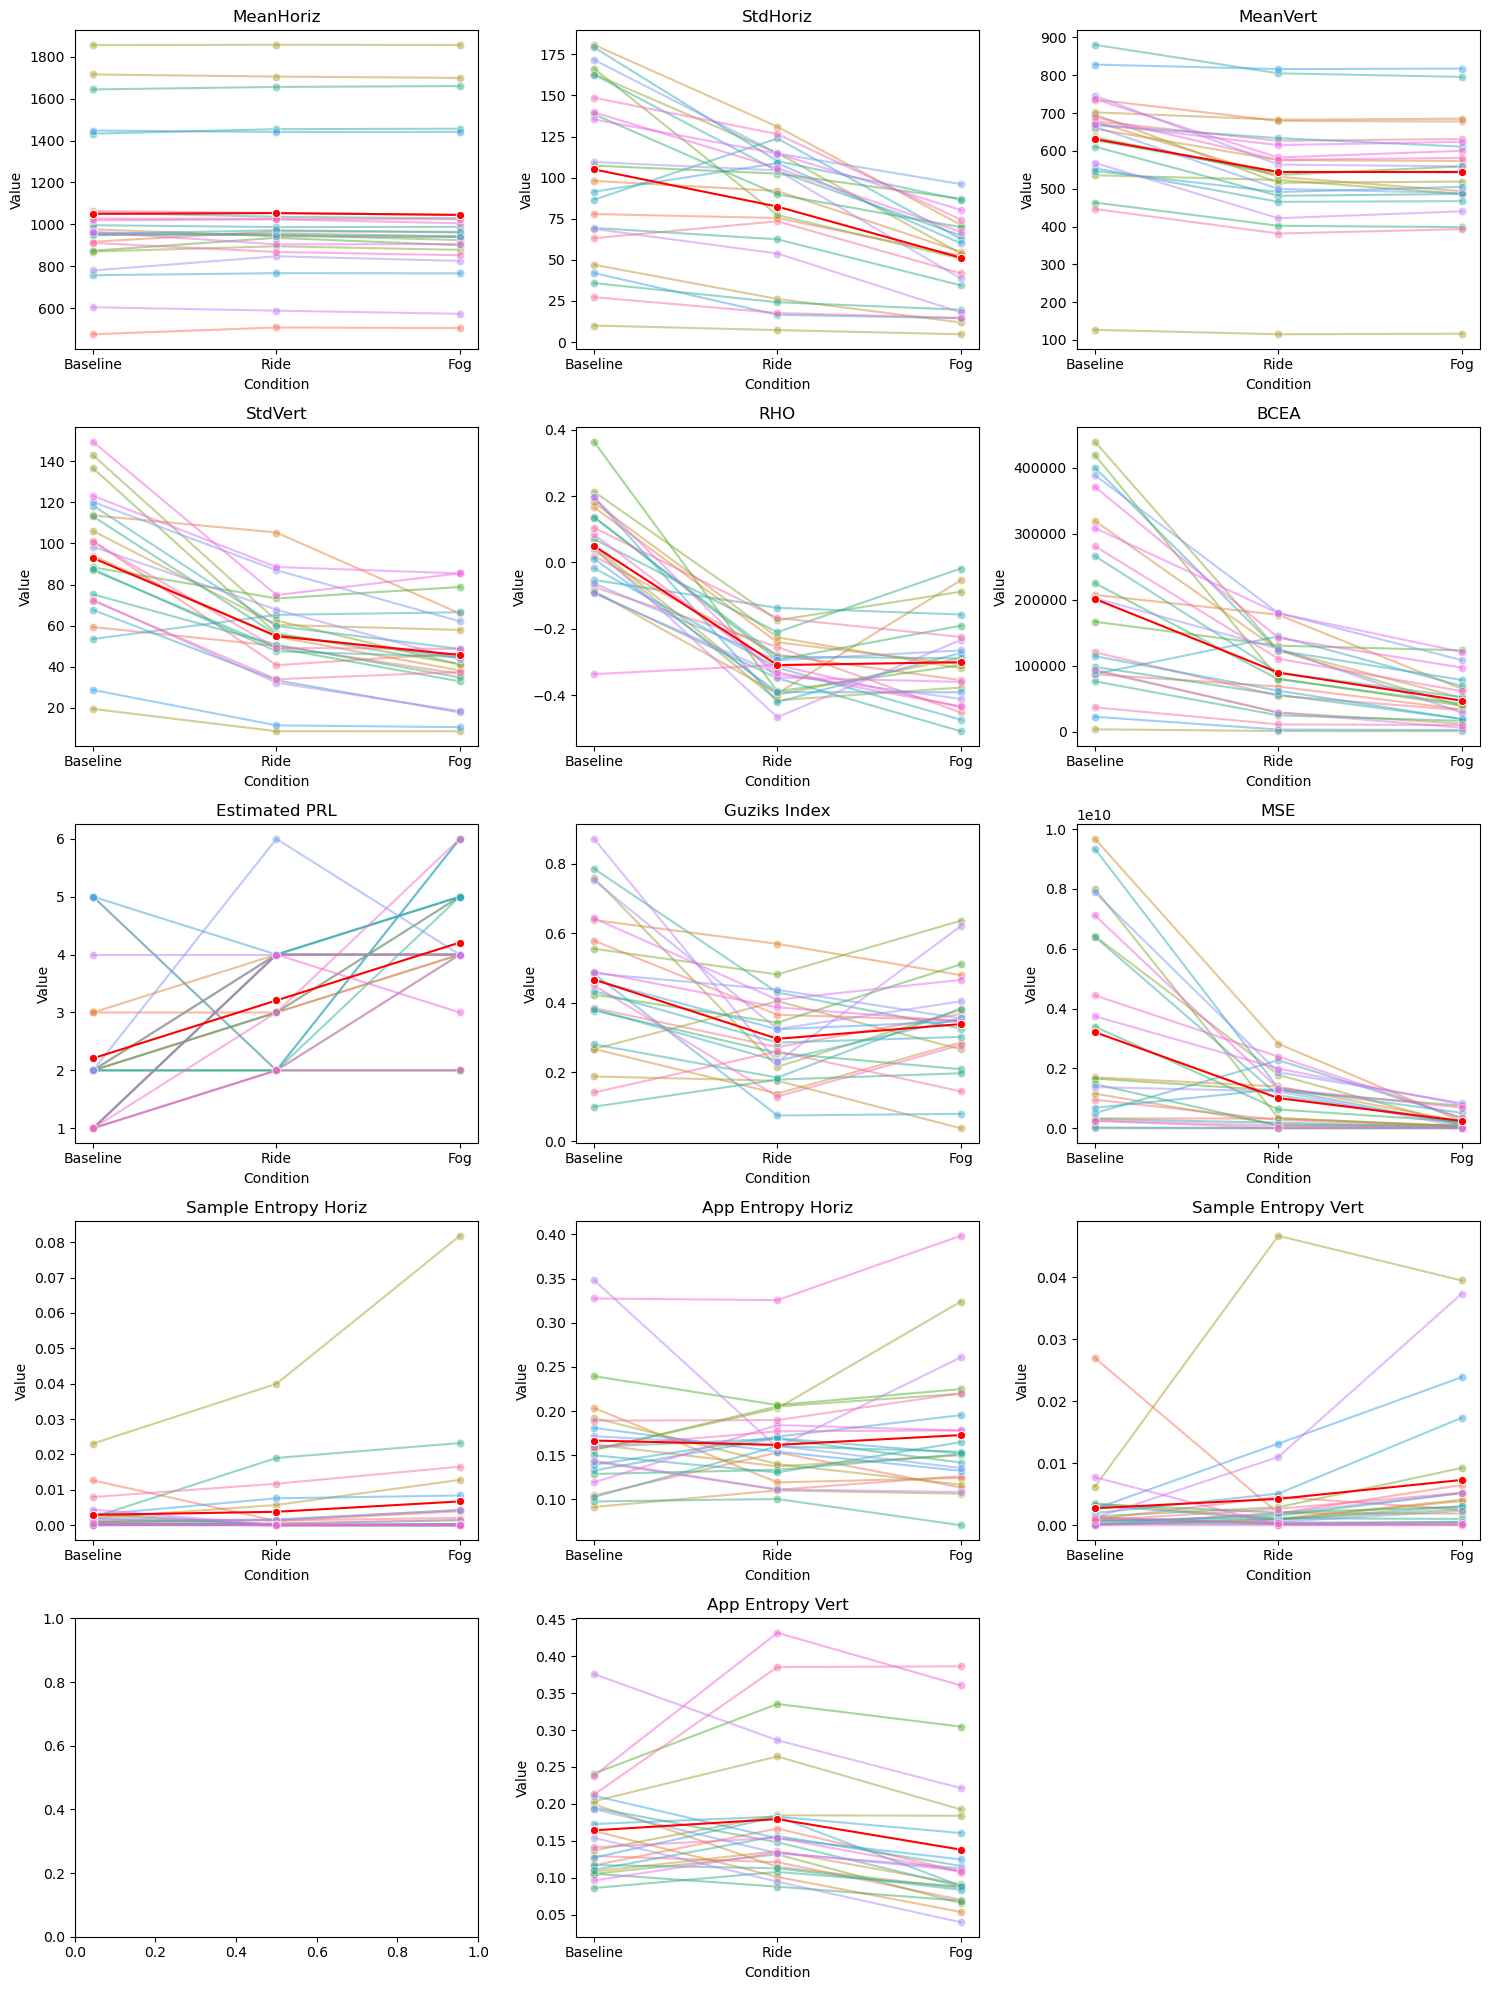

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

variables = df_long['Variable'].unique()
n_vars = len(variables)

n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Ovde ćemo staviti poslednji subplot u sredinu
    if i == n_vars-1:
        # pozicija srednjeg subplota u poslednjem redu
        center_idx = (n_rows-1)*n_cols + n_cols//2
        ax = axes[center_idx]
    else:
        ax = axes[i]

    df_var = df_long[df_long['Variable']==var]
    sns.lineplot(data=df_var, x='Condition', y='Value', hue='SubjectID',
                 marker='o', ax=ax, legend=False, alpha=0.5)
    df_mean = df_var.groupby('Condition')['Value'].mean().reset_index()
    sns.lineplot(data=df_mean, x='Condition', y='Value', color='red', marker='o', ax=ax)
    ax.set_title(var)

# Sakrij prazne ose ako postoje
for j in range(len(variables), len(axes)):
    if axes[j].has_data():
        continue
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


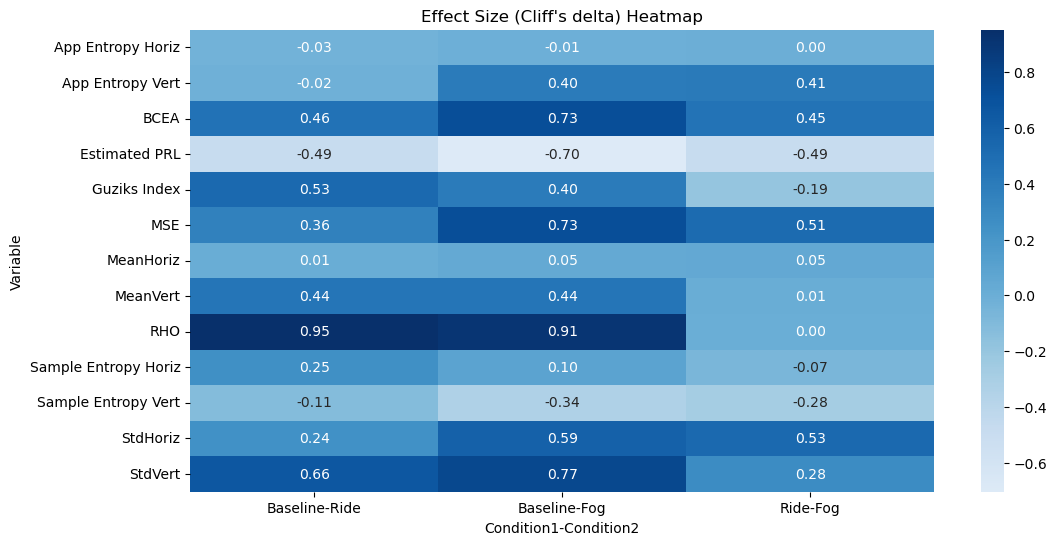

In [ ]:
# Pivot tabela sa Effect size
pivot = df_results.pivot(index='Variable', columns=['Condition1','Condition2'], values='Eff_size')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues", center=0)
plt.title("Effect Size (Cliff's delta) Heatmap")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.anova import AnovaRM
import warnings
warnings.filterwarnings("ignore")

# ---- 1. Calculate rho and standardized delta for each variable ----
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])

common_cols = list(set(baseline_num.columns) & set(ride_num.columns) & set(fog_num.columns))

rho_dict = {}
delta_dict = {}

for col in common_cols:
    # Filter data and remove NaNs
    data = pd.DataFrame({
        'Baseline': baseline_num[col],
        'Ride': ride_num[col],
        'Fog': fog_num[col]
    }).dropna()

    # Mean within-subject correlation
    corr_matrix = np.corrcoef(data.T)
    rho = (np.sum(corr_matrix) - np.trace(corr_matrix)) / (3 * (3 - 1))
    rho_dict[col] = rho

    # Standardized delta (effect size in SD units)
    means = data.mean().values
    centered_means = means - np.mean(means)
    sd_within = data.std(axis=0, ddof=1).mean()  # average SD across conditions
    delta = (np.max(centered_means) - np.min(centered_means)) / 2 / sd_within
    delta_dict[col] = delta

# Optional: exclude variables
exclude_vars = ['Time_min', 'StdDur_ms']
rho_dict = {k: v for k, v in rho_dict.items() if k not in exclude_vars}
delta_dict = {k: v for k, v in delta_dict.items() if k not in exclude_vars}

# ---- 2. Power simulation functions ----
def rm_anova_pval(long_df):
    a = AnovaRM(long_df, 'score', 'subject', within=['condition']).fit()
    return a.anova_table['Pr > F'][0]

def simulate_rm_power(n_subj=24, k=3, rho=0.5, delta=0.8, alpha=0.05, n_sim=500, seed=123):
    rng = np.random.default_rng(seed)
    cov = np.full((k, k), rho)
    np.fill_diagonal(cov, 1.0)
    means = np.linspace(-delta, delta, k)
    reject = 0
    for _ in range(n_sim):
        data = rng.multivariate_normal(mean=means, cov=cov, size=n_subj)
        df = pd.DataFrame(data, columns=[f'Cond{j+1}' for j in range(k)])
        df['subject'] = np.arange(n_subj)
        long_df = df.melt(id_vars='subject', var_name='condition', value_name='score')
        pval = rm_anova_pval(long_df)
        if pval < alpha:
            reject += 1
    return reject / n_sim

# ---- 3a. Conservative overall power (smallest delta) ----
min_delta_var = min(delta_dict, key=delta_dict.get)
conservative_power = simulate_rm_power(
    n_subj=24, k=3, rho=rho_dict[min_delta_var], delta=delta_dict[min_delta_var], alpha=0.05, n_sim=500
)
print(f"Conservative overall power (smallest delta variable '{min_delta_var}'): {conservative_power:.3f}")

# ---- 3b. Average overall power ----
avg_delta = np.mean(list(delta_dict.values()))
avg_rho = np.mean(list(rho_dict.values()))

average_power = simulate_rm_power(
    n_subj=24, k=3, rho=avg_rho, delta=avg_delta, alpha=0.05, n_sim=500
)
print(f"Average overall power (mean delta & mean rho): {average_power:.3f}")
print(avg_delta)
print(avg_rho)

Conservative overall power (smallest delta variable 'MeanHoriz'): 0.300
Average overall power (mean delta & mean rho): 1.000
0.5835521715573108
0.6185098205318067
